In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
import warnings
warnings.filterwarnings("ignore")

In [2]:
clstdnt_data = pd.read_csv('../data/dataset.csv', sep=',')
clstdnt_data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
print("CHECKING NULL OR MISSING VALUES \n", clstdnt_data.isnull().sum())
print("CHECKING DUPLICATED ROWS:", clstdnt_data.duplicated().sum())

CHECKING NULL OR MISSING VALUES 
 Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                 

In [4]:
int_cols = clstdnt_data.select_dtypes(include=['int64']).columns
float_cols = clstdnt_data.select_dtypes(include=['float64']).columns
cat_cols = clstdnt_data.select_dtypes(include=['object']).columns

print("Integer:", len(int_cols))
print("Float:", len(float_cols))
print("Categorical:", len(cat_cols))

Integer: 29
Float: 5
Categorical: 1


In [5]:
le = LabelEncoder()
categorical_cols = clstdnt_data.select_dtypes(include=['object']).columns

target_mapping = {}
if 'Target' in categorical_cols:
    clstdnt_data['Target'] = le.fit_transform(clstdnt_data['Target'])
    target_mapping = {int(idx): label for idx, label in enumerate(le.classes_)}

for col in categorical_cols:
    if col != 'Target':
        clstdnt_data[col] = le.fit_transform(clstdnt_data[col])

int_cols = clstdnt_data.select_dtypes(include=['int64']).columns
float_cols = clstdnt_data.select_dtypes(include=['float64']).columns
cat_cols = clstdnt_data.select_dtypes(include=['object']).columns

print("Integer:", len(int_cols))
print("Float:", len(float_cols))
print("Categorical:", len(cat_cols))

if target_mapping:
    print("\nTarget Encoding Mapping:")
    for idx, label in target_mapping.items():
        print(f"{idx} -> {label}")

Integer: 30
Float: 5
Categorical: 0

Target Encoding Mapping:
0 -> Dropout
1 -> Enrolled
2 -> Graduate


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

X_pipeline = clstdnt_data.drop('Target', axis=1)
y_pipeline = clstdnt_data['Target']

X_train_pipeline, X_test_pipeline, y_train_pipeline, y_test_pipeline = train_test_split(
    X_pipeline, y_pipeline, test_size=0.2, random_state=42, stratify=y_pipeline
)

numeric_features = X_train_pipeline.columns.tolist()

preprocess_pipeline = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='drop'
 )

pipeline_no_leakage = Pipeline(steps=[('preprocess', preprocess_pipeline)])

X_train_pipeline_scaled = pipeline_no_leakage.fit_transform(X_train_pipeline)
X_test_pipeline_scaled = pipeline_no_leakage.transform(X_test_pipeline)

print("Pipeline check (split first, no leakage):")
print("Train shape:", X_train_pipeline_scaled.shape)
print("Test shape :", X_test_pipeline_scaled.shape)

Pipeline check (split first, no leakage):
Train shape: (3539, 34)
Test shape : (885, 34)


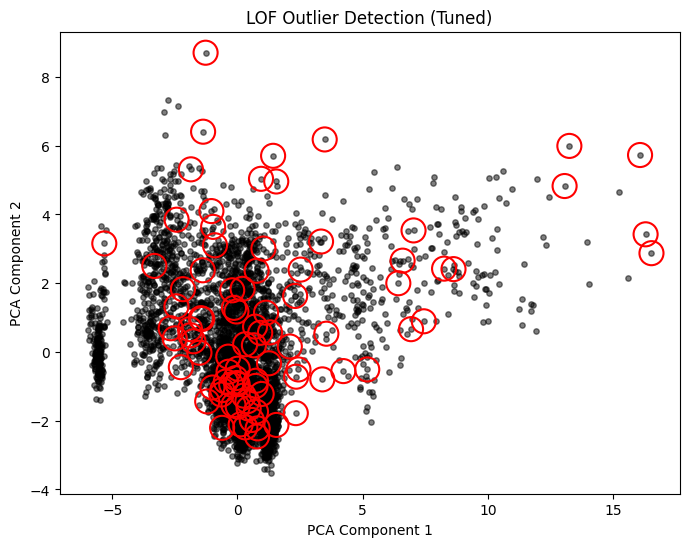

Jumlah outlier: 89


In [7]:
# Pisahkan fitur
X = clstdnt_data.drop('Target', axis=1)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lof = LocalOutlierFactor(
    n_neighbors=40,
    contamination=0.02
)

y_pred = lof.fit_predict(X_scaled)
scores = -lof.negative_outlier_factor_

scores_norm = (scores - scores.min()) / (scores.max() - scores.min())

# PCA untuk visualisasi 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

# Semua titik
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    color='black',
    s=15,
    alpha=0.5
)

# Outlier saja
plt.scatter(
    X_pca[y_pred == -1, 0],
    X_pca[y_pred == -1, 1],
    s=300,
    facecolors='none',
    edgecolors='red',
    linewidth=1.5
)

plt.title("LOF Outlier Detection (Tuned)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

print("Jumlah outlier:", (y_pred == -1).sum())

In [8]:
data_cleaned_with_all_outliers_and_all_features = clstdnt_data.copy()
data_cleaned_with_no_outliers_and_all_features = clstdnt_data[y_pred != -1]
print("Shape with all outliers and all features:", data_cleaned_with_all_outliers_and_all_features.shape)
print("Shape with no outliers and all features:", data_cleaned_with_no_outliers_and_all_features.shape)
data_cleaned_with_all_outliers_and_all_features.to_csv('../data/data_cleaned_with_all_outliers_and_all_features.csv')
data_cleaned_with_no_outliers_and_all_features.to_csv('../data/data_cleaned_with_no_outliers_and_all_features.csv')

Shape with all outliers and all features: (4424, 35)
Shape with no outliers and all features: (4335, 35)


In [9]:
selected_features = [
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Tuition fees up to date',
    'Scholarship holder',
    'Target'
]
data_selected = clstdnt_data[selected_features]
print("Shape of selected features:", data_selected.shape)

data_cleaned_selected_with_all_outliers = data_selected.copy()
data_cleaned_selected_with_no_outliers = data_selected[y_pred != -1]
print("Shape with all outliers and selected features:", data_cleaned_selected_with_all_outliers.shape)
print("Shape with no outliers and selected features:", data_cleaned_selected_with_no_outliers.shape)

data_cleaned_selected_with_all_outliers.to_csv('../data/data_cleaned_selected_with_all_outliers.csv')
data_cleaned_selected_with_no_outliers.to_csv('../data/data_cleaned_selected_with_no_outliers.csv')

Shape of selected features: (4424, 6)
Shape with all outliers and selected features: (4424, 6)
Shape with no outliers and selected features: (4335, 6)
